<a href="https://colab.research.google.com/github/nabhllaaa/Prediksi-Performa-Mahasiswa-CSE/blob/main/BMinggu3_Model_Klasifikasi_Kelompok_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Akurasi Baseline: 0.65
Akurasi Random Forest: 0.65

Laporan Klasifikasi RF:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      0.56      0.71         9
           2       0.56      0.62      0.59         8
           3       0.40      1.00      0.57         2

    accuracy                           0.65        20
   macro avg       0.74      0.80      0.72        20
weighted avg       0.76      0.65      0.66        20



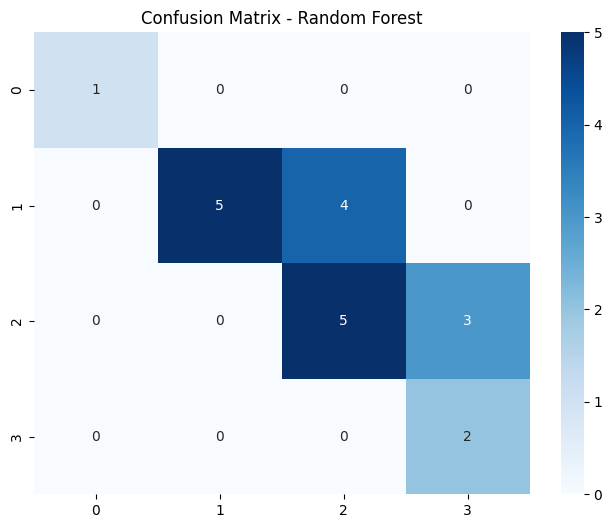

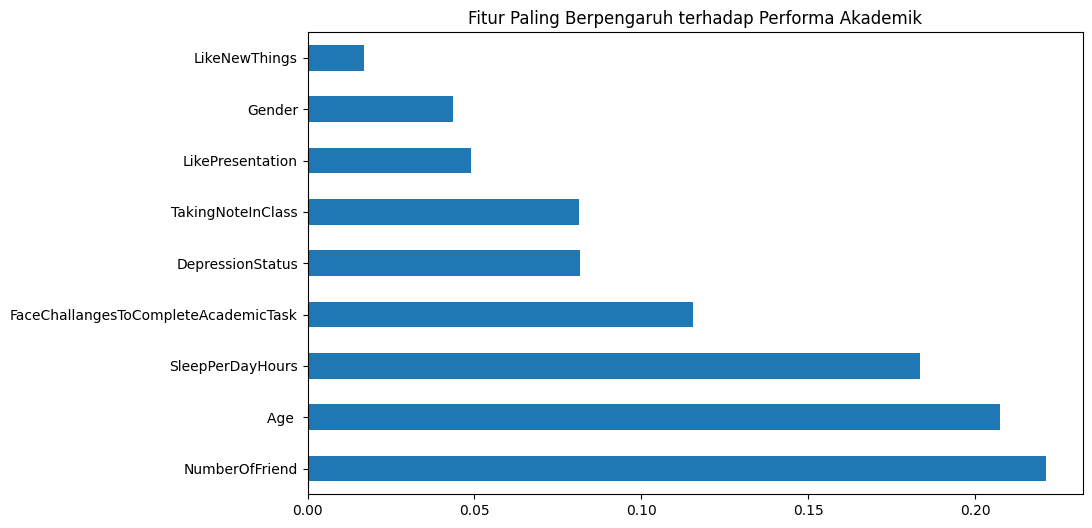

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load Data
df = pd.read_csv('CSE_student_performances.csv')

# 2. Preprocessing & Encoding (Mengatasi Error 'Male')
# Mengisi nilai kosong pada NumberOfFriend dengan median
df['NumberOfFriend'] = df['NumberOfFriend'].fillna(df['NumberOfFriend'].median())

# Mengubah kategori teks menjadi angka
mapping_3 = {'No': 0, 'Sometimes': 1, 'Yes': 2}
mapping_2 = {'No': 0, 'Yes': 1}
mapping_gender = {'Male': 0, 'Female': 1}
mapping_performance = {'Below average': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}

df['Gender'] = df['Gender'].map(mapping_gender)
df['TakingNoteInClass'] = df['TakingNoteInClass'].map(mapping_3)
df['DepressionStatus'] = df['DepressionStatus'].map(mapping_3)
df['FaceChallangesToCompleteAcademicTask'] = df['FaceChallangesToCompleteAcademicTask'].map(mapping_3)
df['LikePresentation'] = df['LikePresentation'].map(mapping_2)
df['LikeNewThings'] = df['LikeNewThings'].map(mapping_2)
df['AcademicPerformance'] = df['AcademicPerformance'].map(mapping_performance)

# Memisahkan Fitur (X) dan Target (y)
X = df.drop('AcademicPerformance', axis=1)
y = df['AcademicPerformance']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Membangun Baseline Model (Logistic Regression)
baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# 4. Membangun Model Final (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 5. Evaluasi & Visualisasi
print("Akurasi Baseline:", accuracy_score(y_test, y_pred_base))
print("Akurasi Random Forest:", accuracy_score(y_test, y_pred_rf))
print("\nLaporan Klasifikasi RF:\n", classification_report(y_test, y_pred_rf))

# Simpan Grafik Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.savefig('confusion_matrix_rf.png')

# Simpan Grafik Feature Importance (Insight)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title('Fitur Paling Berpengaruh terhadap Performa Akademik')
plt.savefig('feature_importance.png')

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Fungsi untuk mengambil metrik secara otomatis
def get_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {'Model': model_name, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

# Membuat list hasil
evaluation_data = [
    get_metrics(y_test, y_pred_base, 'Logistic Regression (Baseline)'),
    get_metrics(y_test, y_pred_rf, 'Random Forest (Final)')
]

# Simpan ke DataFrame dan Export ke CSV
df_eval = pd.DataFrame(evaluation_data)
df_eval.to_csv('tabel_evaluasi_model.csv', index=False)

print("File 'tabel_evaluasi_model.csv' berhasil dibuat!")
df_eval # Menampilkan tabel di Colab

File 'tabel_evaluasi_model.csv' berhasil dibuat!


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Baseline),0.65,0.627143,0.65,0.609197
1,Random Forest (Final),0.65,0.762222,0.65,0.663866
